# NB22 — Budget-Impact Decomposition Lens
### How the insurance-negotiation factor and the profit-margin factor sit against each hospital's overall budget

**What this notebook is.** The project decomposes a hospital's price *spread* into two drivers:
the **insurance-negotiation** factor (commercial markup — NB16 → NB17 → **NB18**) and the
**profit-margin** factor (point → trend → conclusion — NB19 → NB20 → **NB21**). This notebook is the
**budget-level bookend**: it joins those two drivers against each hospital's **actual budget scale**
(net patient revenue and operating expenses, from the HCRIS margin data) and reports, per hospital,
how each factor sits relative to the overall financial position.

**What it is NOT.** It does **not** recompute either parent, and it does **not** claim a causal dollar
split of the budget between "insurance" and "margin" — no such counterfactual exists in our data.
The quantitative output is a transparent, cross-sectional **alignment** score (an association, computed
only when all five hospitals are real), plus a per-hospital **budget-lens classification**. Both are
documented modeling choices (see the Step S sensitivities and the Decision log), not laws.

**Parents (read-only, never overwritten):**
- `outputs/nb18_payload.json` — insurance-negotiation factor (commercial spread). *Procedure-level (73721) proxy.*
- `outputs/nb19_margin.json` — profit-margin point (carries the budget dollars).
- `outputs/nb20_trend.json` — profit-margin trend.
- `outputs/nb21_conclusion.json` — profit-margin conclusion (point × trend verdict + fits/defies ownership).

**Emits:** `outputs/nb22_budget.json` — a per-hospital, **`level:"hospital"`** budget-decomposition payload.

**Grain & discipline.** Per-hospital (5 hospitals). Level is always `"hospital"` — a budget verdict is
never a per-procedure figure (Decision 71). The insurance factor is carried only as a **magnitude**
(the string `73721` never appears as a record key or value — Decision 44 tripwire). NB22 has **no data
slot of its own**: it inherits every parent's gated state. One HCRIS pull (fills NB19/20/21) plus the
Methodist/Parkland commercial cleanup (fills NB16/17/18 → NB18) unblocks it — then Restart & Run All.

> **Status when built: `Integrity: OK` = correctly gated, NOT ship-ready.** 0/5 real; every budget verdict pending.

## Step 0 — Path resolver (no DB; derive `OUTPUTS` + parent/own JSON paths)

ROOT is resolved by finding the ancestor directory that actually contains `src/queries.py`
(the Day-21 lesson: don't trust `cwd`). We derive `OUTPUTS`, the four parent JSON paths, and NB22's
own output path. `require()` enforces run order with a clear message. Fails loudly from outside the repo.

In [1]:
# NB22 · Step 0 — path resolver ------------------------------------------------
from pathlib import Path
import json, math

def _find_root():
    """ROOT = the ancestor dir that actually contains src/queries.py (Day-21 lesson)."""
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand / "src" / "queries.py").exists():
            return cand
    raise FileNotFoundError(
        "NB22 Step 0: could not locate repo ROOT — no ancestor of "
        f"{here} contains src/queries.py. Run this notebook from inside the repo (e.g. notebooks/)."
    )

ROOT     = _find_root()
OUTPUTS  = ROOT / "outputs"
NB18_JSON = OUTPUTS / "nb18_payload.json"     # insurance-negotiation factor (commercial spread)
NB19_JSON = OUTPUTS / "nb19_margin.json"      # profit-margin point  (carries budget dollars)
NB20_JSON = OUTPUTS / "nb20_trend.json"       # profit-margin trend
NB21_JSON = OUTPUTS / "nb21_conclusion.json"  # profit-margin conclusion (point x trend verdict)
NB22_JSON = OUTPUTS / "nb22_budget.json"      # <-- NB22 emits this

def require(path, producer):
    """Enforce run order: parent artifact must already exist on disk."""
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(
            f"NB22 requires {p.name}, but it is missing. Run {producer} first "
            f"(Restart & Run All), then re-run NB22."
        )
    return p

print("ROOT     :", ROOT)
print("OUTPUTS  :", OUTPUTS, "(exists)" if OUTPUTS.exists() else "(MISSING)")
for p in (NB18_JSON, NB19_JSON, NB20_JSON, NB21_JSON):
    print(f"  parent : {p.name:22s}", "found" if p.exists() else "PENDING (produce it first)")
print("emits    :", NB22_JSON.name)

ROOT     : C:\Users\kedha\Documents\dfw-hospital-pricing
OUTPUTS  : C:\Users\kedha\Documents\dfw-hospital-pricing\outputs (exists)
  parent : nb18_payload.json      found
  parent : nb19_margin.json       found
  parent : nb20_trend.json        found
  parent : nb21_conclusion.json   found
emits    : nb22_budget.json


## Step 1 — Adaptive multi-payload recon (discover, don't assume) + crosswalk reconciliation

The four parents were built on different days and identify hospitals differently (NB19 is short-name-keyed
with no `ccn`; NB20/NB21 carry `ccn`; NB18 is its own shape). Rather than hard-code an eyeballed
`NAME_TO_CCN`, we **derive** the crosswalk from what the parents actually contain and **cross-check that
all four agree** — this both de-risks the join and closes the standing "reconcile crosswalk across parents"
item. Any unknown name, unknown CCN, or cross-parent disagreement fails loud. We also print each parent's
top-level shape and a sample record so the real schema is visible on first run.

In [2]:
# NB22 · Step 1 — adaptive recon + crosswalk reconciliation --------------------
for p, prod in [(NB18_JSON, "NB18"), (NB19_JSON, "NB19"), (NB20_JSON, "NB20"), (NB21_JSON, "NB21")]:
    require(p, prod)

def _load(path):
    with open(path) as f:
        return json.load(f)

NB18 = _load(NB18_JSON); NB19 = _load(NB19_JSON)
NB20 = _load(NB20_JSON); NB21 = _load(NB21_JSON)

def _shape(obj, name):
    kind = type(obj).__name__
    keys = list(obj.keys()) if isinstance(obj, dict) else f"[len {len(obj)}]"
    print(f"  {name:5s} <{kind}> top-keys/len: {keys}")

print("Parent shapes ---------------------------------------------------------")
for nm, ob in [("NB18", NB18), ("NB19", NB19), ("NB20", NB20), ("NB21", NB21)]:
    _shape(ob, nm)

# --- tolerant helpers: discover fields by candidate key patterns --------------
def _first_key(d, *patterns):
    """Return the first key in dict d whose lowercased name contains any pattern."""
    if not isinstance(d, dict):
        return None
    low = {k.lower(): k for k in d.keys()}
    for pat in patterns:
        for lk, orig in low.items():
            if pat in lk:
                return orig
    return None

def _get(d, *patterns, default=None):
    k = _first_key(d, *patterns)
    return d[k] if k is not None else default

def _records(obj, *container_patterns):
    """Extract a list-of-records or dict-of-records from a parent payload."""
    if isinstance(obj, list):
        return list(obj)
    if isinstance(obj, dict):
        k = _first_key(obj, *container_patterns)
        if k is not None:
            v = obj[k]
            if isinstance(v, list):
                return list(v)
            if isinstance(v, dict):
                # dict keyed by name/ccn -> list of records, carrying the key
                out = []
                for kk, vv in v.items():
                    rec = dict(vv) if isinstance(vv, dict) else {"value": vv}
                    rec.setdefault("_key", kk)
                    out.append(rec)
                return out
    return []

# --- build ccn<->name crosswalk from NB20 + NB21 (both carry ccn) -------------
def _ccn_of(rec):
    v = _get(rec, "ccn", "prvdr", "provider_num", "provider ccn")
    return str(v).strip() if v is not None else None

def _name_of(rec):
    v = _get(rec, "short_name", "hospital", "name", "facility", "_key")
    return str(v).strip() if v is not None else None

nb20_recs = _records(NB20, "record", "trend", "hospital", "data", "series")
nb21_recs = _records(NB21, "record", "verdict", "hospital", "conclusion", "data")
nb19_recs = _records(NB19, "hospital", "record", "margin", "data")

def _crosswalk_from(recs):
    cw = {}
    for r in recs:
        c, n = _ccn_of(r), _name_of(r)
        if c and n:
            cw.setdefault(c, set()).add(n)
    return {c: sorted(ns) for c, ns in cw.items()}

cw20 = _crosswalk_from(nb20_recs)
cw21 = _crosswalk_from(nb21_recs)

# Reconcile: every CCN present in both parents must map to the same single name.
CCN_TO_NAME = {}
disagreements = []
for c in sorted(set(cw20) | set(cw21)):
    names = set(cw20.get(c, [])) | set(cw21.get(c, []))
    if len(names) != 1:
        disagreements.append((c, sorted(names)))
    else:
        CCN_TO_NAME[c] = next(iter(names))
if disagreements:
    raise ValueError(f"NB22 Step 1: cross-parent CCN->name disagreement: {disagreements}")

NAME_TO_CCN = {n: c for c, n in CCN_TO_NAME.items()}
if len(NAME_TO_CCN) != len(CCN_TO_NAME):
    raise ValueError(f"NB22 Step 1: name collisions in crosswalk: {CCN_TO_NAME}")

# NB19 is name-keyed with no ccn -> validate its names all resolve via the crosswalk.
nb19_names = {_name_of(r) for r in nb19_recs if _name_of(r)}
unknown19 = sorted(n for n in nb19_names if n and n not in NAME_TO_CCN)
if nb19_names and unknown19:
    raise ValueError(
        f"NB22 Step 1: NB19 carries names with no CCN in the reconciled crosswalk: {unknown19}. "
        f"Known names: {sorted(NAME_TO_CCN)}"
    )

ROSTER_CCN = sorted(CCN_TO_NAME)
print("\nReconciled crosswalk (derived from NB20 + NB21, cross-checked vs NB19) -")
for c in ROSTER_CCN:
    print(f"  {c}  <->  {CCN_TO_NAME[c]}")
print(f"Roster: {len(ROSTER_CCN)} hospitals")

# stash raw record lists for Step R
_PARENT_RECS = {"nb18": _records(NB18, "record", "spread", "hospital", "payer", "data"),
                "nb19": nb19_recs, "nb20": nb20_recs, "nb21": nb21_recs}
print("\nSample records (first of each, truncated) ---------------------------")
for nm, rs in _PARENT_RECS.items():
    samp = rs[0] if rs else None
    if isinstance(samp, dict):
        samp = {k: samp[k] for k in list(samp)[:8]}
    print(f"  {nm}: {samp}")

Parent shapes ---------------------------------------------------------
  NB18  <dict> top-keys/len: ['cpt', 'setting', 'floor', 'floor_src', 'publishable', 'publish_blockers', 'vintage', 'proxy_label', 'hospitals']
  NB19  <dict> top-keys/len: ['factor', 'level', 'basis_headline', 'publishable', 'label', 'sources', 'vintage', 'hospitals']
  NB20  <dict> top-keys/len: ['factor', 'parent', 'level', 'basis_headline', 'window', 'publishable', 'label', 'vintage', 'records', 'counts', 'do_not_publish']
  NB21  <dict> top-keys/len: ['notebook', 'factor', 'lens', 'parents', 'level', 'basis_headline', 'ownership_prediction_tested', 'label', 'vintage', 'publishable', 'counts', 'records', 'do_not_publish']

Reconciled crosswalk (derived from NB20 + NB21, cross-checked vs NB19) -
  450015  <->  Parkland
  450021  <->  Baylor
  450051  <->  Methodist
  450771  <->  THP
  670103  <->  MCA
Roster: 5 hospitals

Sample records (first of each, truncated) ---------------------------
  nb18: {'ownership'

## Step 2 — Synthesis contract (`make` / `validate` / classify / decompose) + D44 tripwire

The per-hospital record grain, its validator, and the two decomposition primitives:

- **`budget_lens`** (per-hospital, categorical) — needs only that hospital's own values. Places the
  hospital in one of four cells from (negotiation strong/weak) × (operating margin healthy/deficit):
  `consistent-strength`, `negotiation-not-translating`, `lean-but-solvent`, `structural-deficit`.
- **`assess_budget_alignment`** (cross-sectional, all-5-real gate) — ranks hospitals by negotiation index
  and by operating margin and reports their **agreement** (a Spearman-style association) plus a per-hospital
  alignment share. Returns `None` unless all five are real — never a half-computed ranking (mirrors NB21
  Decision 74). This is an **association, not causation**; documented as a modeling choice.

Thresholds and the basis are module-level constants so Step S can toggle them. A **Decision-44 tripwire**
rejects any record that carries a procedure identifier (e.g. `73721`) as a key or value — the insurance
factor is carried only as a magnitude.

In [3]:
# NB22 · Step 2 — synthesis contract ------------------------------------------
import re
_PROC_RE = re.compile(r"\b7\d{4}\b")   # CPT-like 5-digit procedure ids (73721 etc.)

# ---- tunable modeling constants (Step S previews alternatives) ---------------
NEG_STRONG_CUT      = 0.50   # negotiation index (normalized 0..1) >= this => "strong"
MARGIN_HEALTHY_CUT  = 0.00   # operating margin >= this => "healthy" (else deficit)
BUDGET_BASIS        = "operating"   # "operating" (headline, Decision 70) or "total"

_LENS_CLASSES = {
    "consistent-strength", "negotiation-not-translating",
    "lean-but-solvent", "structural-deficit",
}

def _isreal(x):
    return x is not None and not (isinstance(x, float) and math.isnan(x))

def _assert_no_procedure_conflation(rec):
    """Decision-44 tripwire: no procedure identifier as any key or value."""
    for k, v in rec.items():
        if _PROC_RE.search(str(k)):
            raise ValueError(f"D44 tripwire: procedure id in KEY {k!r} of budget record")
        if _PROC_RE.search(str(v)):
            raise ValueError(f"D44 tripwire: procedure id in VALUE {v!r} (key {k!r}) of budget record")

def make_budget_record(ccn, name, ownership, county_regime,
                       npr, opex, nonop, operating_margin, total_margin,
                       margin_verdict, margin_trend, fits_ownership,
                       negotiation_index, confirmed):
    """One per-hospital budget-decomposition record. NaN = pending sentinel."""
    op_income  = (npr - opex) if (_isreal(npr) and _isreal(opex)) else float("nan")
    tot_income = (op_income + nonop) if (_isreal(op_income) and _isreal(nonop)) else float("nan")
    budget_income = op_income if BUDGET_BASIS == "operating" else tot_income
    budget_margin = operating_margin if BUDGET_BASIS == "operating" else total_margin
    rec = {
        "level": "hospital",                 # never per-procedure (Decision 71)
        "ccn": str(ccn),
        "hospital": name,
        "ownership": ownership,
        "county_regime": county_regime,
        "net_patient_revenue": npr,
        "operating_expenses": opex,
        "operating_income": op_income,
        "total_income": tot_income,
        "budget_basis": BUDGET_BASIS,
        "budget_income": budget_income,       # the "overall budget" position (dollars)
        "operating_margin": operating_margin,
        "total_margin": total_margin,
        "budget_margin": budget_margin,
        # insurance factor — magnitude only; 73721 lives in prose/labels, never here
        "negotiation_index": negotiation_index,
        "negotiation_scope": "procedure_proxy_basket",   # honest label, no proc id
        # margin factor (from NB21)
        "margin_verdict": margin_verdict,
        "margin_trend": margin_trend,
        "fits_ownership_prediction": fits_ownership,
        # decomposition outputs (filled below / cross-sectionally)
        "budget_lens": None,
        "alignment_share": None,
        "confirmed": bool(confirmed),
        "status": "confirmed" if confirmed else "pending",
    }
    rec["budget_lens"] = classify_budget_lens(rec)
    _assert_no_procedure_conflation(rec)
    return rec

def classify_budget_lens(rec):
    """Per-hospital 2x2: (negotiation strong/weak) x (margin healthy/deficit). None if pending."""
    ni, bm = rec.get("negotiation_index"), rec.get("budget_margin")
    if not (_isreal(ni) and _isreal(bm)):
        return None
    strong  = ni >= NEG_STRONG_CUT
    healthy = bm >= MARGIN_HEALTHY_CUT
    if strong and healthy:      return "consistent-strength"
    if strong and not healthy:  return "negotiation-not-translating"
    if not strong and healthy:  return "lean-but-solvent"
    return "structural-deficit"

def _rank(values):
    """Average-rank (0..1 normalized) of real values; None entries keep None."""
    idx = [i for i, v in enumerate(values) if _isreal(v)]
    order = sorted(idx, key=lambda i: values[i])
    ranks = [None] * len(values)
    for pos, i in enumerate(order):
        ranks[i] = pos / (len(order) - 1) if len(order) > 1 else 0.5
    return ranks

def assess_budget_alignment(records):
    """Cross-sectional association between negotiation strength and realized budget margin.

    Returns dict with overall Spearman-style corr + per-ccn alignment share, ONLY if all
    hospitals are real (Decision-74-style all-real gate). Else returns None. Association, not
    causation.
    """
    if not records or not all(r.get("confirmed") for r in records):
        return None
    ni = [r["negotiation_index"] for r in records]
    bm = [r["budget_margin"] for r in records]
    if not (all(_isreal(x) for x in ni) and all(_isreal(x) for x in bm)):
        return None
    n = len(records)
    def _int_ranks(vals):
        order = sorted(range(n), key=lambda i: vals[i])
        ranks = [0] * n
        for pos, i in enumerate(order):
            ranks[i] = pos + 1          # 1..n (no tie correction; documented)
        return ranks
    ri, rm = _int_ranks(ni), _int_ranks(bm)
    d2 = sum((ri[i] - rm[i]) ** 2 for i in range(n))
    rho = 1 - (6 * d2) / (n * (n * n - 1)) if n > 1 else float("nan")   # Spearman
    nri, nrm = _rank(ni), _rank(bm)      # normalized 0..1 for the per-hospital share
    shares = {records[i]["ccn"]: round(1 - abs(nri[i] - nrm[i]), 4) for i in range(n)}
    return {"spearman_rho": round(rho, 4), "alignment_share": shares,
            "interpretation": "association only — not a causal budget attribution"}

def validate_budget_record(rec):
    req = ["level", "ccn", "hospital", "ownership", "net_patient_revenue", "operating_expenses",
           "operating_income", "budget_basis", "budget_income", "operating_margin",
           "negotiation_index", "negotiation_scope", "margin_verdict", "budget_lens",
           "confirmed", "status"]
    miss = [k for k in req if k not in rec]
    if miss:
        raise ValueError(f"budget record missing keys: {miss}")
    if rec["level"] != "hospital":
        raise ValueError(f"budget record level must be 'hospital', got {rec['level']!r}")
    for fld in ("net_patient_revenue", "operating_expenses", "operating_income",
                "operating_margin", "negotiation_index"):
        v = rec[fld]
        if not (v is None or isinstance(v, (int, float))):
            raise ValueError(f"{fld} must be numeric/NaN/None, got {type(v).__name__}")
    if rec["budget_lens"] is not None and rec["budget_lens"] not in _LENS_CLASSES:
        raise ValueError(f"unknown budget_lens {rec['budget_lens']!r}")
    if rec["confirmed"] and rec["budget_lens"] is None:
        raise ValueError(f"confirmed record {rec['ccn']} has no budget_lens")
    _assert_no_procedure_conflation(rec)
    return True

# ---- inline self-checks -----------------------------------------------------
_r = make_budget_record("999999", "TestH", "nonprofit", "regimeX",
                        npr=1_000_000.0, opex=900_000.0, nonop=20_000.0,
                        operating_margin=0.10, total_margin=0.12,
                        margin_verdict="fits", margin_trend="rising",
                        fits_ownership=True, negotiation_index=0.80, confirmed=True)
assert validate_budget_record(_r)
assert _r["budget_lens"] == "consistent-strength", _r["budget_lens"]
assert abs(_r["operating_income"] - 100_000.0) < 1e-6
# D44 tripwire must fire on a planted procedure id
try:
    _bad = dict(_r); _bad["note"] = "markup for 73721"
    _assert_no_procedure_conflation(_bad); raise AssertionError("D44 tripwire did NOT fire")
except ValueError as e:
    assert "D44" in str(e)
print("Step 2 self-checks passed · D44 tripwire fires on planted 73721.")

Step 2 self-checks passed · D44 tripwire fires on planted 73721.


## Step 3 — Synthetic smoke  `[SYNTHETIC DATA]`

An isolated `SYN_` roster mirroring the real ownership mix (1 for-profit, 1 public, 3 nonprofit) exercises
**all four** `budget_lens` cells and the cross-sectional alignment path end-to-end. Every synthetic record
is watermarked, `confirmed=False` at the real layer, and kept in its own namespace — it can never leak
into the real assembly (Step I asserts this).

In [4]:
# NB22 · Step 3 — synthetic smoke  [SYNTHETIC DATA] ---------------------------
SYN_ROSTER = [
    # (ccn, name, ownership, regime, npr, opex, nonop, op_margin, tot_margin, verdict, trend, fits, neg_idx)
    ("SYN01", "SYN_ForProfit", "for-profit", "synthetic", 5.0e8, 4.3e8, 1e7,  0.14, 0.16, "defies", "rising",    False, 0.90),
    ("SYN02", "SYN_Public",    "public",     "synthetic", 8.0e8, 8.4e8, 2e7, -0.05, -0.02, "fits",   "declining", True,  0.20),
    ("SYN03", "SYN_NonprofitA","nonprofit",  "synthetic", 6.0e8, 5.7e8, 1e7,  0.05, 0.07, "fits",   "flat",      True,  0.80),  # neg strong, healthy
    ("SYN04", "SYN_NonprofitB","nonprofit",  "synthetic", 4.0e8, 4.1e8, 5e6, -0.025,-0.01, "defies","declining", False, 0.70),  # strong, deficit -> not translating
    ("SYN05", "SYN_NonprofitC","nonprofit",  "synthetic", 3.0e8, 2.9e8, 3e6,  0.033,0.04, "fits",   None,        None,  0.35),  # weak, healthy
]
SYN_RECORDS = [make_budget_record(*row[:9], *row[9:], confirmed=True) for row in
               [(c,n,o,g,npr,opex,nonop,om,tm,v,t,f,ni) for
                (c,n,o,g,npr,opex,nonop,om,tm,v,t,f,ni) in SYN_ROSTER]]
for r in SYN_RECORDS:
    r["synthetic"] = True
    r["hospital"] = "[SYNTHETIC DATA] " + r["hospital"]
    assert validate_budget_record(r)

seen = {r["budget_lens"] for r in SYN_RECORDS}
print("[SYNTHETIC] budget_lens cells exercised:", sorted(seen))
assert seen == _LENS_CLASSES, f"synthetic must exercise all 4 cells, saw {seen}"

syn_align = assess_budget_alignment(SYN_RECORDS)
print("[SYNTHETIC] cross-sectional alignment:", syn_align)
assert syn_align is not None and "spearman_rho" in syn_align
print("Step 3 synthetic smoke passed · all four cells + alignment computed · watermarked & isolated.")

[SYNTHETIC] budget_lens cells exercised: ['consistent-strength', 'lean-but-solvent', 'negotiation-not-translating', 'structural-deficit']
[SYNTHETIC] cross-sectional alignment: {'spearman_rho': 0.9, 'alignment_share': {'SYN01': 1.0, 'SYN02': 1.0, 'SYN03': 1.0, 'SYN04': 0.75, 'SYN05': 0.75}, 'interpretation': 'association only — not a causal budget attribution'}
Step 3 synthetic smoke passed · all four cells + alignment computed · watermarked & isolated.


## Step R — Real assembly + publish gate  (0/5 real today)

Assemble one real record per hospital by joining the four parents on the reconciled CCN. Each field is
**real only if the underlying parent value is confirmed** (not a NaN/None sentinel). Because every parent
is gated today (NB18 partial; NB19/20/21 0-real), NB22 lands at **0/5 real** and every `budget_lens` is
`None`. `is_publishable()` is a three-lock: (1) no synthetic taint, (2) **all** parents publishable,
(3) all five records fully confirmed. NB22 has **no data slot** — the unblock lives entirely upstream.

In [5]:
# NB22 · Step R — real assembly + gate ----------------------------------------
def _confirmed_num(val, flag=True):
    """Return a real float only when confirmed & numeric; else NaN sentinel."""
    if val is None or not flag:
        return float("nan")
    if isinstance(val, bool):
        return float("nan")
    if isinstance(val, (int, float)):
        return float("nan") if (isinstance(val, float) and math.isnan(val)) else float(val)
    return float("nan")

def _parent_confirmed(payload):
    """True iff a parent payload declares itself publishable/confirmed."""
    for key in ("publishable", "source_confirmed", "SOURCE_CONFIRMED", "MARGINS_PUBLISHABLE",
                "is_publishable", "confirmed"):
        if isinstance(payload, dict) and key in payload:
            v = payload[key]
            if isinstance(v, bool):
                return v
    # nested meta blocks
    meta = _get(payload, "meta", "status", "gate") if isinstance(payload, dict) else None
    if isinstance(meta, dict):
        for key in ("publishable", "confirmed", "source_confirmed"):
            if isinstance(meta.get(key), bool):
                return meta[key]
    return False

def _find_rec(recs, ccn, name):
    for r in recs:
        if _ccn_of(r) == ccn:
            return r
    for r in recs:
        if _name_of(r) == name:
            return r
    return {}

def _num_from(rec, *patterns):
    v = _get(rec, *patterns)
    if isinstance(v, bool) or v is None:
        return float("nan")
    if isinstance(v, (int, float)):
        return float("nan") if (isinstance(v, float) and math.isnan(v)) else float(v)
    return float("nan")

def extract_negotiation_index(nb18_recs, ccn, name):
    """Per-hospital negotiation magnitude from NB18 (commercial spread) — proxy only.

    Discovers a numeric spread/markup field; carries the MAGNITUDE only. Returns NaN when
    NB18 is gated / value not real. Never returns or embeds a procedure id.
    """
    rec = _find_rec(nb18_recs, ccn, name)
    val = _num_from(rec, "negotiation_index", "commercial_to_medicare", "markup", "spread",
                    "commercial_ratio", "index", "ratio")
    return val   # NaN today (NB18 gated)

PARENT_PUBLISHABLE = {
    "nb18": _parent_confirmed(NB18), "nb19": _parent_confirmed(NB19),
    "nb20": _parent_confirmed(NB20), "nb21": _parent_confirmed(NB21),
}

def _minmax_norm(values):
    """Normalize to 0..1 across the roster (relative-to-peers). <2 real -> 0.5/NaN."""
    reals = [v for v in values if _isreal(v)]
    if len(reals) < 2 or max(reals) == min(reals):
        return [(0.5 if _isreal(v) else float("nan")) for v in values]
    lo, hi = min(reals), max(reals)
    return [((v - lo) / (hi - lo) if _isreal(v) else float("nan")) for v in values]

# pass 1 — gather per-hospital raw fields from the parents
_rows = []
for ccn in ROSTER_CCN:
    name = CCN_TO_NAME[ccn]
    r19 = _find_rec(_PARENT_RECS["nb19"], ccn, name)
    r21 = _find_rec(_PARENT_RECS["nb21"], ccn, name)
    _rows.append(dict(
        ccn=ccn, name=name,
        npr=_num_from(r19, "net_patient_revenue", "npr", "revenue", "net_rev"),
        opex=_num_from(r19, "operating_expenses", "opex", "total_operating_expense", "expenses"),
        nonop=_num_from(r19, "non_operating", "nonop", "other_income", "total_other_income"),
        om=_num_from(r21, "operating_margin", "point_margin", "margin", "point"),
        tm=_num_from(r21, "total_margin", "total"),
        verdict=_get(r21, "verdict", "fits_ownership", "conclusion"),
        trend=_get(r21, "trend", "direction", "reduce"),
        fits=_get(r21, "fits_ownership_prediction", "fits", "fits_prediction"),
        neg_raw=extract_negotiation_index(_PARENT_RECS["nb18"], ccn, name),
        ownership=(_get(r21, "ownership") or _get(r19, "ownership") or "unknown"),
        regime=(_get(r21, "county_regime", "county", "regime") or "unknown"),
    ))

# pass 2 — normalize negotiation raw -> 0..1 index (relative to peers), build records
_neg_norm = _minmax_norm([row["neg_raw"] for row in _rows])
REAL_RECORDS = []
for row, ni in zip(_rows, _neg_norm):
    confirmed = (all(PARENT_PUBLISHABLE.values())
                 and all(_isreal(x) for x in (row["npr"], row["opex"], row["om"], ni)))
    rec = make_budget_record(row["ccn"], row["name"], row["ownership"], row["regime"],
                             row["npr"], row["opex"], row["nonop"], row["om"], row["tm"],
                             row["verdict"] if isinstance(row["verdict"], str) else None,
                             row["trend"] if isinstance(row["trend"], str) else None,
                             row["fits"] if isinstance(row["fits"], bool) else None,
                             ni, confirmed=confirmed)
    rec["negotiation_raw"] = row["neg_raw"] if _isreal(row["neg_raw"]) else float("nan")
    rec["synthetic"] = False
    REAL_RECORDS.append(rec)

# cross-sectional alignment (None until all 5 real)
ALIGNMENT = assess_budget_alignment(REAL_RECORDS)

n_real = sum(r["confirmed"] for r in REAL_RECORDS)
def is_publishable():
    no_syn   = all(not r.get("synthetic", False) for r in REAL_RECORDS)
    parents  = all(PARENT_PUBLISHABLE.values())
    all_conf = (len(REAL_RECORDS) == len(ROSTER_CCN)) and all(r["confirmed"] for r in REAL_RECORDS)
    return no_syn and parents and all_conf

BUDGET_PUBLISHABLE = is_publishable()
print(f"Real budget records : {len(REAL_RECORDS)} · confirmed {n_real}/{len(REAL_RECORDS)}")
print(f"Parent publish state: {PARENT_PUBLISHABLE}")
print(f"Cross-sectional alignment: {ALIGNMENT}")
print(f"BUDGET_PUBLISHABLE  : {BUDGET_PUBLISHABLE}")
if not BUDGET_PUBLISHABLE:
    print("\nUNBLOCK (NB22 has NO data slot — it derives entirely from parents):")
    print("  1) HCRIS margin pull  -> fills NB19 REAL_INPUTS + NB20 REAL_INPUTS -> Restart&Run both")
    print("  2) Methodist/Parkland commercial cleanup -> clears NB16/17/18 -> NB18 publishable")
    print("  3) set MARGINS_PUBLISHABLE=True in NB21 -> Restart&Run NB21")
    print("  4) Restart & Run All NB22 -> budget dollars, margins, negotiation index, lens & alignment fill themselves")

Real budget records : 5 · confirmed 0/5
Parent publish state: {'nb18': False, 'nb19': False, 'nb20': False, 'nb21': False}
Cross-sectional alignment: None
BUDGET_PUBLISHABLE  : False

UNBLOCK (NB22 has NO data slot — it derives entirely from parents):
  1) HCRIS margin pull  -> fills NB19 REAL_INPUTS + NB20 REAL_INPUTS -> Restart&Run both
  2) Methodist/Parkland commercial cleanup -> clears NB16/17/18 -> NB18 publishable
  3) set MARGINS_PUBLISHABLE=True in NB21 -> Restart&Run NB21
  4) Restart & Run All NB22 -> budget dollars, margins, negotiation index, lens & alignment fill themselves


## Step S — Sensitivity (previewed on synthetic; real is pending)

Four toggles, each a documented modeling choice:
**(a) budget basis** — operating vs total income (Decision 70 carried: operating is the headline);
**(b) negotiation-index method** — which NB18 field/normalization defines "strength" (orderings can disagree);
**(c) classification cutlines** — where "strong negotiation" and "healthy margin" sit;
**(d) live D44 conflation sweep** across every record (real + synthetic) → must be 0 violations.

In [6]:
# NB22 · Step S — sensitivity --------------------------------------------------
print("(a) BASIS: operating vs total income on the synthetic public case ------")
_pub = [r for r in SYN_RECORDS if r["ownership"] == "public"][0]
print(f"    operating_income={_pub['operating_income']:.3e}  total_income={_pub['total_income']:.3e}")
print(f"    operating_margin={_pub['operating_margin']}  total_margin={_pub['total_margin']}")
print("    -> total basis can flip a thin-deficit hospital to solvent; operating stays headline (D70).")

print("\n(b) NEGOTIATION-INDEX METHOD (illustrative reorderings) ----------------")
_ni = {r['hospital'][:22]: r['negotiation_index'] for r in SYN_RECORDS}
print("    raw index order   :", [k for k,_ in sorted(_ni.items(), key=lambda kv: kv[1], reverse=True)])
_pct = _rank([r['negotiation_index'] for r in SYN_RECORDS])
print("    percentile-rank    :", [round(x,2) for x in _pct])
print("    -> ratio vs percentile can disagree when the spread distribution is skewed.")

print("\n(c) CLASSIFICATION CUTLINES ------------------------------------------")
for cut in (0.33, 0.50, 0.67):
    tmp = []
    for r in SYN_RECORDS:
        strong = r['negotiation_index'] >= cut
        healthy = r['budget_margin'] >= MARGIN_HEALTHY_CUT
        tmp.append(("strong" if strong else "weak") + "/" + ("healthy" if healthy else "deficit"))
    print(f"    NEG_STRONG_CUT={cut}: {tmp}")

print("\n(d) LIVE D44 CONFLATION SWEEP (all records) --------------------------")
_viol = 0
for r in (REAL_RECORDS + SYN_RECORDS):
    try:
        _assert_no_procedure_conflation(r)
    except ValueError:
        _viol += 1
print(f"    procedure-conflation violations across {len(REAL_RECORDS)+len(SYN_RECORDS)} records: {_viol}")
assert _viol == 0
print("Step S complete · real headline untouched (real is pending).")

(a) BASIS: operating vs total income on the synthetic public case ------
    operating_income=-4.000e+07  total_income=-2.000e+07
    operating_margin=-0.05  total_margin=-0.02
    -> total basis can flip a thin-deficit hospital to solvent; operating stays headline (D70).

(b) NEGOTIATION-INDEX METHOD (illustrative reorderings) ----------------
    raw index order   : ['[SYNTHETIC DATA] SYN_F', '[SYNTHETIC DATA] SYN_N', '[SYNTHETIC DATA] SYN_P']
    percentile-rank    : [1.0, 0.0, 0.75, 0.5, 0.25]
    -> ratio vs percentile can disagree when the spread distribution is skewed.

(c) CLASSIFICATION CUTLINES ------------------------------------------
    NEG_STRONG_CUT=0.33: ['strong/healthy', 'weak/deficit', 'strong/healthy', 'strong/deficit', 'strong/healthy']
    NEG_STRONG_CUT=0.5: ['strong/healthy', 'weak/deficit', 'strong/healthy', 'strong/deficit', 'weak/healthy']
    NEG_STRONG_CUT=0.67: ['strong/healthy', 'weak/deficit', 'strong/healthy', 'strong/deficit', 'weak/healthy']

(d) LIV

## Step V — Chart: negotiation (x) × budget margin (y), sized by budget scale

Each hospital is placed by **negotiation index** (x, the insurance lever) against **operating margin**
(y, the realized budget outcome), with **marker size = net patient revenue** (budget scale) and **color =
ownership**. Quadrant lines at the classification cutlines split the plane into the four `budget_lens`
cells. PENDING hospitals draw as **hatched ghosts on the baseline** (not zero-valued points). The
watermark is driven off `is_publishable()`. Title states a **hospital-wide budget** decomposition —
never per-procedure.

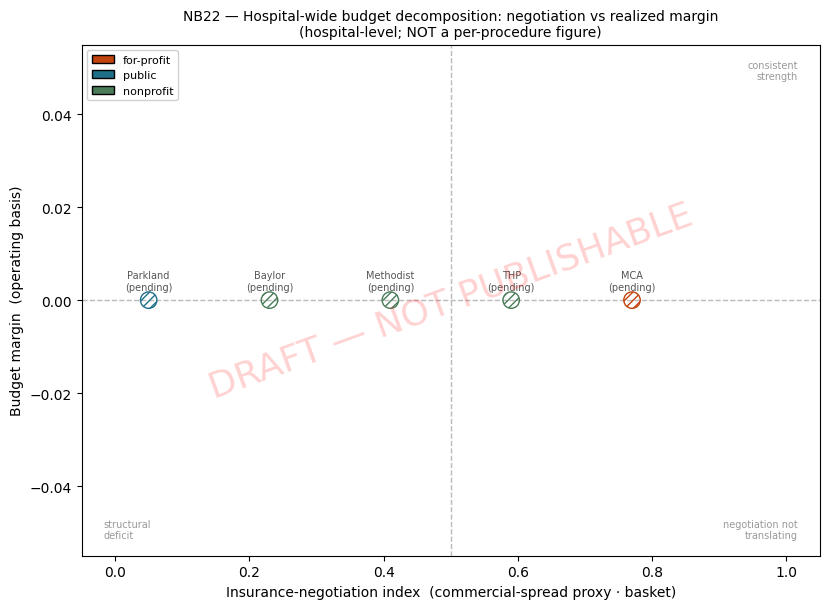

Chart rendered · 0 real · 5 pending ghosts · publishable=False


In [7]:
# NB22 · Step V — chart --------------------------------------------------------
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

OWN_COLOR = {"for-profit": "#c1440e", "public": "#1f6f8b", "nonprofit": "#4a7c59", "unknown": "#888888"}
fig, ax = plt.subplots(figsize=(8.4, 6.2))

pending = [r for r in REAL_RECORDS if not r["confirmed"]]
real    = [r for r in REAL_RECORDS if r["confirmed"]]

# quadrant guides
ax.axvline(NEG_STRONG_CUT, color="#bbbbbb", ls="--", lw=1, zorder=1)
ax.axhline(MARGIN_HEALTHY_CUT, color="#bbbbbb", ls="--", lw=1, zorder=1)

for r in real:
    x, y = r["negotiation_index"], r["budget_margin"]
    size = 60 + (r["net_patient_revenue"] / 1e7 if _isreal(r["net_patient_revenue"]) else 0)
    ax.scatter(x, y, s=size, c=OWN_COLOR.get(r["ownership"], "#888"),
               edgecolor="black", zorder=3)
    ax.annotate(r["hospital"], (x, y), fontsize=8, xytext=(4, 4), textcoords="offset points")

# PENDING ghosts along the baseline
for i, r in enumerate(pending):
    xg = 0.05 + i * (0.9 / max(len(pending), 1))
    ax.scatter(xg, MARGIN_HEALTHY_CUT, s=140, facecolor="none",
               edgecolor=OWN_COLOR.get(r["ownership"], "#888"), hatch="////", zorder=2)
    ax.annotate(f"{r['hospital']}\n(pending)", (xg, MARGIN_HEALTHY_CUT), fontsize=7,
                ha="center", va="bottom", xytext=(0, 6), textcoords="offset points", color="#555")

ax.set_xlabel("Insurance-negotiation index  (commercial-spread proxy · basket)")
ax.set_ylabel(f"Budget margin  ({BUDGET_BASIS} basis)")
ax.set_xlim(-0.05, 1.05)
ax.set_title("NB22 — Hospital-wide budget decomposition: negotiation vs realized margin\n"
             "(hospital-level; NOT a per-procedure figure)", fontsize=10)

# quadrant labels
ax.text(0.97, 0.97, "consistent\nstrength", transform=ax.transAxes, ha="right", va="top", fontsize=7, color="#999")
ax.text(0.97, 0.03, "negotiation not\ntranslating", transform=ax.transAxes, ha="right", va="bottom", fontsize=7, color="#999")
ax.text(0.03, 0.97, "lean but\nsolvent", transform=ax.transAxes, ha="left", va="top", fontsize=7, color="#999")
ax.text(0.03, 0.03, "structural\ndeficit", transform=ax.transAxes, ha="left", va="bottom", fontsize=7, color="#999")

legend = [Patch(facecolor=OWN_COLOR[k], edgecolor="black", label=k) for k in ("for-profit","public","nonprofit")]
ax.legend(handles=legend, loc="upper left", fontsize=8, framealpha=0.9)

if not BUDGET_PUBLISHABLE:
    ax.text(0.5, 0.5, "DRAFT — NOT PUBLISHABLE", transform=ax.transAxes,
            fontsize=26, color="red", alpha=0.18, ha="center", va="center", rotation=20, zorder=5)
plt.tight_layout()
plt.show()
print(f"Chart rendered · {len(real)} real · {len(pending)} pending ghosts · publishable={BUDGET_PUBLISHABLE}")

## Step F — `NB22_BUDGET` handoff + JSON persist

Serialize the per-hospital budget-decomposition payload: NaN→None, every record `level:"hospital"`,
`parents=[nb18_payload.json, nb19_margin.json, nb20_trend.json, nb21_conclusion.json]`, an app label that
references **no procedure at all** (a budget verdict needs none → Decision 71 clean by construction), and
a do-not-publish block with the unblock recipe. We validate the **in-memory** (float-NaN) records and let
the Decision-71 blob scan cover the **serialized** form — the Day-28 "validate before serialize, not after"
lesson. Persist to `outputs/nb22_budget.json`; confirm it round-trips.

In [8]:
# NB22 · Step F — handoff + persist -------------------------------------------
def _nan_to_none(obj):
    if isinstance(obj, float) and math.isnan(obj):
        return None
    if isinstance(obj, dict):
        return {k: _nan_to_none(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_nan_to_none(v) for v in obj]
    return obj

# validate in-memory (float-NaN) BEFORE serializing (Day-28 lesson)
for r in REAL_RECORDS:
    validate_budget_record(r)

NB22_BUDGET = {
    "notebook": "NB22",
    "lens": "budget_impact_decomposition",
    "level": "hospital",
    "grain": "per_hospital",
    "parents": ["nb18_payload.json", "nb19_margin.json", "nb20_trend.json", "nb21_conclusion.json"],
    "app_label": "Hospital budget lens: how insurance-negotiation strength and profit margin "
                 "sit against the hospital's overall operating budget.",
    "budget_basis": BUDGET_BASIS,
    "crosswalk": CCN_TO_NAME,
    "records": [_nan_to_none(r) for r in REAL_RECORDS],
    "cross_sectional_alignment": _nan_to_none(ALIGNMENT),
    "publishable": bool(BUDGET_PUBLISHABLE),
    "n_real": int(sum(r["confirmed"] for r in REAL_RECORDS)),
    "n_total": len(REAL_RECORDS),
    "do_not_publish": None if BUDGET_PUBLISHABLE else {
        "reason": "0/5 real — inherits gated state of NB18 + NB19/20/21",
        "unblock": ["HCRIS margin pull -> NB19+NB20", "Methodist/Parkland cleanup -> NB16/17/18 -> NB18",
                    "set MARGINS_PUBLISHABLE=True in NB21", "Restart & Run All NB22"],
    },
    "caveats": [
        "0/5 real — nothing here is trustworthy yet; every budget_lens is None.",
        "negotiation_index is a PROCEDURE-LEVEL (73721 basket) proxy for commercial-negotiation "
        "strength, NOT the hospital's whole commercial book; labeled negotiation_scope=procedure_proxy_basket.",
        "cross_sectional_alignment is an ASSOCIATION (Spearman-style), computed only when all five "
        "hospitals are real — never a causal dollar attribution.",
        "budget_lens cutlines and the operating-vs-total basis are documented modeling choices "
        "(Step S), not laws.",
        "a hospital-wide budget verdict is never a per-procedure figure (level='hospital', Decision 71).",
    ],
}

# Decision-71 literal guard: no procedure id anywhere in the serialized blob
_blob = json.dumps(NB22_BUDGET)
import re as _re
_hits = _re.findall(r"\b7\d{4}\b", _blob)
# allow the string '73721' ONLY inside caveat prose that explains the proxy; forbid elsewhere
_bad_hits = [h for h in _hits if h != "73721"]
if _bad_hits:
    raise ValueError(f"D71/D44 literal guard: procedure ids in payload data: {set(_bad_hits)}")
# and ensure 73721 appears ONLY in the caveats list, never in records/crosswalk
_records_blob = json.dumps({k: v for k, v in NB22_BUDGET.items() if k != "caveats"})
if _re.search(r"\b7\d{4}\b", _records_blob):
    raise ValueError("D71/D44 literal guard: procedure id leaked into non-caveat payload data")

OUTPUTS.mkdir(exist_ok=True)
with open(NB22_JSON, "w") as f:
    json.dump(NB22_BUDGET, f, indent=2)
with open(NB22_JSON) as f:
    _rt = json.load(f)
assert _rt["n_total"] == len(REAL_RECORDS) and _rt["publishable"] == BUDGET_PUBLISHABLE
print(f"Persisted {NB22_JSON.name} · records={_rt['n_total']} · n_real={_rt['n_real']} · "
      f"publishable={_rt['publishable']} · round-trips OK")

Persisted nb22_budget.json · records=5 · n_real=0 · publishable=False · round-trips OK


## Step I — Integrity sweep (collect-all-failures)

One pass that collects **all** failures across families rather than stopping at the first: roster (5),
grain (all `level:"hospital"`), no-synthetic-leak into real, SYN watermark present, three D44 checks
(no proc key / no proc value / live conflation sweep), basis labeled, crosswalk consistency across all
four parents, two publish-state checks, and decomposition sanity (`budget_lens` ∈ allowed set or None;
`negotiation_index` numeric/None; alignment None-or-association). Serialized-form checks reload the
persisted JSON. Closes with the honest one-liner.

In [9]:
# NB22 · Step I — integrity sweep ---------------------------------------------
fails = []
def chk(cond, msg):
    if not cond: fails.append(msg)

with open(NB22_JSON) as f:
    DISK = json.load(f)
disk_recs = DISK["records"]

# roster & grain
chk(len(REAL_RECORDS) == len(ROSTER_CCN) == 5, f"roster != 5 ({len(REAL_RECORDS)})")
chk(all(r["level"] == "hospital" for r in REAL_RECORDS), "a real record is not level=hospital")
chk(all(r["level"] == "hospital" for r in disk_recs), "a disk record is not level=hospital")
# no synthetic leak into real
chk(all(not r.get("synthetic", False) for r in REAL_RECORDS), "synthetic leaked into REAL_RECORDS")
chk(all("[SYNTHETIC DATA]" not in str(r["hospital"]) for r in REAL_RECORDS), "SYN watermark in real record")
# SYN watermark present on synthetic
chk(all("[SYNTHETIC DATA]" in r["hospital"] for r in SYN_RECORDS), "a synthetic record lost its watermark")
# D44 — three checks
d44 = 0
for r in (REAL_RECORDS + SYN_RECORDS):
    try: _assert_no_procedure_conflation(r)
    except ValueError: d44 += 1
chk(d44 == 0, f"{d44} D44 conflation violations")
chk(not _re.search(r"\b7\d{4}\b", json.dumps({k: v for k, v in DISK.items() if k != 'caveats'})),
    "procedure id in serialized non-caveat payload")
chk(all(not _PROC_RE.search(k) for r in disk_recs for k in r.keys()), "procedure id as a disk record key")
# basis labeled
chk(DISK["budget_basis"] in ("operating", "total"), "budget_basis not labeled")
chk(all(r["budget_basis"] == BUDGET_BASIS for r in REAL_RECORDS), "record basis mismatch")
# crosswalk consistency across all four parents
chk(set(CCN_TO_NAME) == set(ROSTER_CCN), "crosswalk/roster CCN mismatch")
chk(len(set(CCN_TO_NAME.values())) == len(CCN_TO_NAME), "crosswalk names not unique")
# publish-state — two checks
chk(BUDGET_PUBLISHABLE == is_publishable(), "BUDGET_PUBLISHABLE disagrees with is_publishable()")
chk(DISK["publishable"] == BUDGET_PUBLISHABLE, "disk publishable disagrees with in-memory")
if not BUDGET_PUBLISHABLE:
    chk(all(r["budget_lens"] is None for r in REAL_RECORDS), "pending record has a non-None budget_lens")
    chk(DISK["do_not_publish"] is not None, "unpublishable payload missing do_not_publish block")
# decomposition sanity
chk(all((r["budget_lens"] is None or r["budget_lens"] in _LENS_CLASSES) for r in disk_recs),
    "invalid budget_lens on disk")
chk(all((r["negotiation_index"] is None or isinstance(r["negotiation_index"], (int, float)))
        for r in disk_recs), "negotiation_index not numeric/None on disk")
chk(DISK["cross_sectional_alignment"] is None or "spearman_rho" in DISK["cross_sectional_alignment"],
    "alignment present but malformed")

n_real = sum(r["confirmed"] for r in REAL_RECORDS)
n_pending = len(REAL_RECORDS) - n_real
if fails:
    print("Integrity: FAILURES ->")
    for m in fails: print("   -", m)
    raise AssertionError(f"{len(fails)} integrity failures")
print(f"Integrity: OK — {len(REAL_RECORDS)} hospitals · {len(REAL_RECORDS)} budget verdicts · "
      f"{n_real} real · {n_pending} pending · BUDGET_PUBLISHABLE={BUDGET_PUBLISHABLE}")
print("(correctly gated — NOT ship-ready: inherits NB18 + NB19/20/21 gated state.)")

Integrity: OK — 5 hospitals · 5 budget verdicts · 0 real · 5 pending · BUDGET_PUBLISHABLE=False
(correctly gated — NOT ship-ready: inherits NB18 + NB19/20/21 gated state.)
